In [10]:
# imports
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import PIL
from PIL import ImageOps

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import ipywidgets as widgets
from ipywidgets import interact

import numpy as np
import pandas as pd
from pathlib import Path
import itertools
import time

In [11]:
# load dataset MNIST
transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root      = 'data',
    train     = True,
    download  = True,
    transform = transform
)

test_data = datasets.MNIST(
    root      = 'data',
    train     = False,
    download  = True,
    transform = transform
)

train_loader = DataLoader(dataset = train_data, batch_size = 4096, num_workers = 4, pin_memory = True)
test_loader = DataLoader(dataset = test_data, batch_size = 4096, num_workers = 4, pin_memory = True)

In [12]:
print("# Train data:", len(train_data))
print("# Test data:", len(test_data))

# Train data: 60000
# Test data: 10000


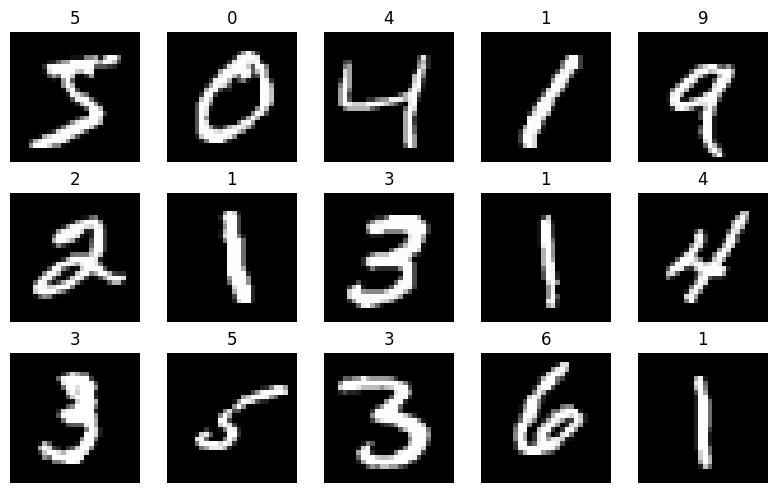

In [13]:
# grid of sample digits
fig, axes = plt.subplots(3, 5, figsize=(8, 5))

for i, ax in enumerate(axes.flat):
    img, label = train_data[i]
    ax.imshow(img.squeeze(), cmap = "grey")
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()    

In [14]:
# see the grey value as a float
img, label = train_data[0]
print("Label", label)
print("Shape", img.shape)
print(np.array(img.numpy()))

Label 5
Shape torch.Size([1, 28, 28])
[[[0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.        ]
  [0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.        ]
  [0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.         0.         0.
   0.         0.         0.         0.        ]
  [0.         0.         0.         0.         0.         0.
   0.         0.         

In [15]:
# simple model
class DigitNet(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),     
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)
    
model_gpu = DigitNet().cuda()
model_cpu = DigitNet()

In [16]:
# loss function, optimizer with learning rate lr
lr = 0.001
loss_fn_gpu = nn.CrossEntropyLoss()
loss_fn_cpu = nn.CrossEntropyLoss()
optimizer_gpu = torch.optim.Adam(params = model_gpu.parameters(), lr = lr)
optimizer_cpu = torch.optim.Adam(params = model_cpu.parameters(), lr = lr)

In [17]:
# learning rate decay 
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size = 3, gamma = 0.0001)

In [18]:
# gpu traning

# device = torch.device("cuda")
# X.to(device, non_blocking = True), y.to(device, non_blocking = True)

epochs = 10
start = time.time()

for epoch in range(epochs):
    total_loss = 0
    for X, y in train_loader:
        X, y = X.cuda(non_blocking = True), y.cuda(non_blocking = True)

        preds = model_gpu(X)
        loss = loss_fn_gpu(preds, y)

        optimizer_gpu.zero_grad()   # delete old gradients
        loss.backward()             # calculate new gradients through backpropagations (chain rule)
        optimizer_gpu.step()        # update weights and bias

        total_loss += loss.item()

    print(f"epoch {epoch + 1}: loss = {total_loss:.4f}")

print(f"{epochs} epochs in {time.time()-start}s")

epoch 1: loss = 24.9660
epoch 2: loss = 10.4757
epoch 3: loss = 6.5019
epoch 4: loss = 5.3172
epoch 5: loss = 4.7477
epoch 6: loss = 4.3790
epoch 7: loss = 4.0865
epoch 8: loss = 3.8283
epoch 9: loss = 3.5915
epoch 10: loss = 3.3734
10 epochs in 69.0815658569336s


In [19]:
# cpu training
epochs = 10
start = time.time()

for epoch in range(epochs):
    total_loss = 0
    for X, y in train_loader:
        
        preds = model_cpu(X)
        loss = loss_fn_cpu(preds, y)

        optimizer_cpu.zero_grad()
        loss.backward()
        optimizer_cpu.step()

        total_loss += loss.item()

    print(f"epoch {epoch + 1}: loss = {total_loss:.4f}")

print(f"{epochs} epochs in {time.time()-start}s")

epoch 1: loss = 25.3013
epoch 2: loss = 10.8192
epoch 3: loss = 6.6567
epoch 4: loss = 5.3796
epoch 5: loss = 4.7571
epoch 6: loss = 4.3568
epoch 7: loss = 4.0498
epoch 8: loss = 3.7907
epoch 9: loss = 3.5610
epoch 10: loss = 3.3523
10 epochs in 76.73784756660461s


In [20]:
# eval model_gpu
correct = 0
total = 0
model_gpu.eval()

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.cuda(non_blocking = True), y.cuda(non_blocking = True)
        preds = model_gpu(X)
        correct += (preds.argmax(1) == y).sum().item()
        total += y.size(0)

print("Accuracy:", correct / total)

Accuracy: 0.9387


In [21]:
# eval model_cpu
correct = 0
total = 0
model_cpu.eval()

with torch.no_grad():
    for X, y in test_loader:
        preds = model_cpu(X)
        correct += (preds.argmax(1) == y).sum().item()
        total += y.size(0)

print("Accuracy:", correct / total)

Accuracy: 0.9387


Ergebnis nach ein paar Testläufen mit verschiedenen Parametern:
- GPU ist nicht schneller als CPU
- Beide kommen auf das gleiche Ergebnis

Vermutung:
- es dauert genauso lange die Berechnungen für Cuda und die GPU vorzubereiten, als die CPU braucht, um die Berechnungen direkt selbst zu erledigen
- GPU sollte bei größeren Modellen / Batchsizes deutlich schneller sein.

Idee:
- Ein kleiner Benchmark, der verschiedene Parameter durchläuft und die benötigte Zeit berechnet.
- Danach wird ein etwas komplexeres Modell erstellt und der Benchmark wiederholt.

In [22]:
# Benchmark
def benchmark(model, loader, device, epochs=1):
    
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fn = torch.nn.CrossEntropyLoss()

    start = time.time()

    for _ in range(epochs):
        for X, y in loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            preds = model(X)
            loss = loss_fn(preds, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    end = time.time()

    # maybe not take the time for one epoch and instead do a couple and then take the mean of them
    
    return end - start

In [23]:
# Parameters
batch_sizes = [32, 128, 512, 2048, 8192]
num_workers_list = [0, 4, 8, 12]
pin_memory_list = [False, True]
devices = ["cpu", "cuda"]

In [24]:
# Run the benchmark for model
epochs = 1
results = []

for batch_size, num_workers, pin_memory, device in itertools.product(
    batch_sizes, num_workers_list, pin_memory_list, devices
):
    print(f"Testing: batch={batch_size}, workers={num_workers}, pin={pin_memory}, device={device}")

    loader = DataLoader(
        dataset     = train_data,
        batch_size  = batch_size,
        num_workers = num_workers,
        pin_memory  = pin_memory,
        shuffle     = True
    )

    model = DigitNet()
    t = benchmark(model, loader, device, epochs = epochs)

    results.append({
    "batch_size": batch_size,
    "num_workers": num_workers,
    "pin_memory": pin_memory,
    "device": device,
    "time": t
    })

timings_df = pd.DataFrame(results)

Testing: batch=32, workers=0, pin=False, device=cpu
Testing: batch=32, workers=0, pin=False, device=cuda
Testing: batch=32, workers=0, pin=True, device=cpu
Testing: batch=32, workers=0, pin=True, device=cuda
Testing: batch=32, workers=4, pin=False, device=cpu
Testing: batch=32, workers=4, pin=False, device=cuda
Testing: batch=32, workers=4, pin=True, device=cpu
Testing: batch=32, workers=4, pin=True, device=cuda
Testing: batch=32, workers=8, pin=False, device=cpu
Testing: batch=32, workers=8, pin=False, device=cuda
Testing: batch=32, workers=8, pin=True, device=cpu
Testing: batch=32, workers=8, pin=True, device=cuda


KeyboardInterrupt: 

In [ ]:
timings_df

,batch_size,num_workers,pin_memory,device,time
0,32,0,False,cpu,8.782050
1,32,0,False,cuda,8.786067
2,32,0,True,cpu,8.647626
3,32,0,True,cuda,8.415725
4,32,4,False,cpu,10.564658
...,...,...,...,...,...
75,8192,8,True,cuda,9.611100
76,8192,12,False,cpu,10.632439
77,8192,12,False,cuda,10.658735
78,8192,12,True,cpu,10.544004


In [ ]:
# plot benchmark fn
colors = {"cpu": "green", "cuda": "red"}
markers = {False: "o", True: "x"}

def plot_benchmark(x_axis, fixed_workers, fixed_batch):
    plt.figure(figsize=(10, 6))

    # Filter the dataset depending on which axis we use
    if x_axis == "batch_size":
        subset = timings_df[timings_df["num_workers"] == fixed_workers]
    else:
        subset = timings_df[timings_df["batch_size"] == fixed_batch]

    # Plot each device + pin combination
    for device in ["cpu", "cuda"]:
        for pin in [False, True]:
            d = subset[(subset.device == device) &
                       (subset.pin_memory == pin)]

            plt.scatter(
                d[x_axis],
                d["time"],
                c=colors[device],
                marker=markers[pin],
                s=80,
                label=f"{device}, pin={pin}"
            )

    plt.xscale("log")        
    plt.xticks([32, 128, 512, 2048, 8192], ["32", "128", "512", "2024", "8196"])      
    plt.title(f"Training Time vs {x_axis}")
    plt.xlabel(x_axis)
    plt.ylabel("Time (s)")
    plt.grid(True)
    plt.legend()
    plt.show()

In [ ]:
# Widgets
interact(
    plot_benchmark,
    x_axis=["batch_size", "num_workers"],
    fixed_workers = widgets.Dropdown(
        options     = sorted(timings_df["num_workers"].unique()),
        description = "num_workers",
        value       = timings_df["num_workers"].min()
    ),
    fixed_batch = widgets.Dropdown(
        options     = sorted(timings_df["batch_size"].unique()),
        description = "batch_size",
        value       = timings_df["batch_size"].min()
    )
)

interactive(children=(Dropdown(description='x_axis', options=('batch_size', 'num_workers'), value='batch_size'…

<function __main__.plot_benchmark(x_axis, fixed_workers, fixed_batch)>

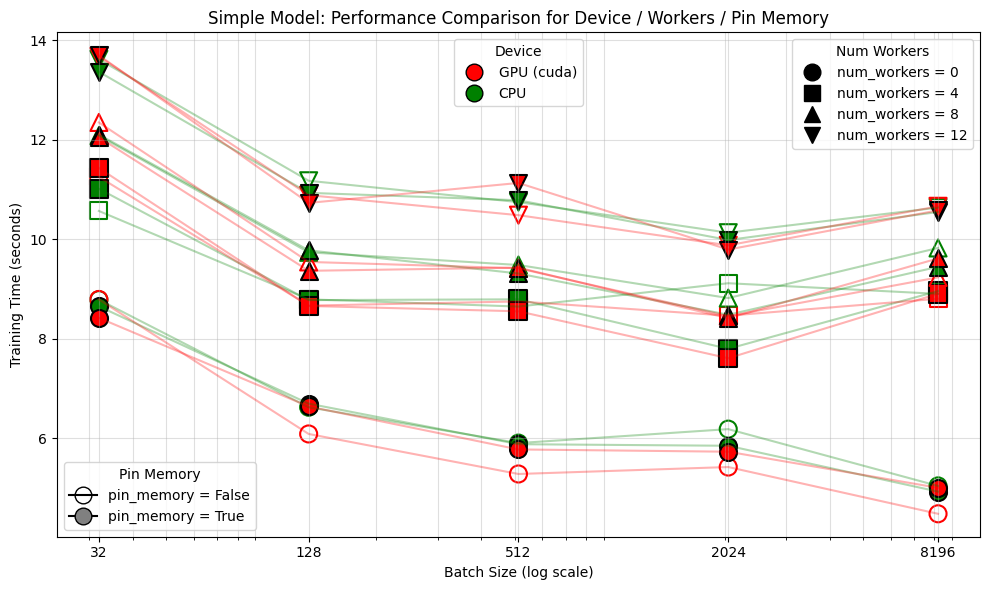

In [ ]:
# complete overview for model
color_map  = {"cuda": "red", "cpu": "green"}
marker_map = {0:"o", 4:"s", 8:"^", 12:"v"}

plt.figure(figsize = (10, 6))

for _, row in timings_df.iterrows():
    batch   = row["batch_size"]
    workers = row["num_workers"]
    pin     = row["pin_memory"]
    device  = row["device"]
    t       = row["time"]

    color  = color_map[device]
    marker = marker_map[workers]

    if pin:
        facecolor = color
        edgecolor = "black"
    else:
        facecolor = "none"
        edgecolor = color

    plt.scatter(
        batch, t,
        marker    = marker,
        facecolor = facecolor,
        edgecolor = edgecolor,
        s         = 150,
        linewidth = 1.5,
    )

for (device, pin, workers), group in timings_df.groupby(["device", "pin_memory", "num_workers"]):
    plt.plot(group["batch_size"], group["time"], color = color_map[device], alpha = 0.3)

# legend for device (color)
device_handles = [
    Line2D([0], [0], 
           marker          = 'o', 
           color           = 'none', 
           markerfacecolor = 'red', 
           markeredgecolor = 'black', 
           markersize      = 12, 
           label           = 'GPU (cuda)'
    ),
    Line2D([0], [0], 
           marker          = 'o', 
           color           = 'none', 
           markerfacecolor = 'green', 
           markeredgecolor = 'black', 
           markersize      = 12, 
           label           = 'CPU'
    ),
]

# legend for pin_memory (filled vs hollow)
pin_handles = [
    Line2D([0], [0], 
           marker          = 'o', 
           color           = 'black', 
           markerfacecolor = 'none',
           markersize      = 12, 
           label           = 'pin_memory = False'
    ),
    Line2D([0], [0], 
           marker          = 'o', 
           color           = 'black', 
           markerfacecolor = 'gray',
           markersize      = 12, 
           label           = 'pin_memory = True'
    ),
]

# legend for num_workers (marker shapes)
marker_handles = [
    Line2D([0], [0], 
           marker          = marker_map[w], 
           color           = 'black',
           markerfacecolor = 'black', 
           markersize      = 12, 
           linestyle       = 'none',
           label           = f"num_workers = {w}")
    for w in sorted(marker_map.keys())
]

# legends
legend1 = plt.legend(handles = device_handles, title = "Device", loc = "upper center")
plt.gca().add_artist(legend1)

legend2 = plt.legend(handles = pin_handles, title = "Pin Memory", loc = "lower left")
plt.gca().add_artist(legend2)

plt.legend(handles = marker_handles, title = "Num Workers", loc = "upper right")

plt.xscale("log")
plt.xticks([32, 128, 512, 2048, 8192], ["32", "128", "512", "2024", "8196"])
plt.xlabel("Batch Size (log scale)")
plt.ylabel("Training Time (seconds)")
plt.title("Simple Model: Performance Comparison for Device / Workers / Pin Memory")
plt.grid(True, which = "both", alpha = 0.4)
plt.tight_layout()
plt.show()

In [ ]:
# more complex model
class DigitNetCplx(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),                                
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        return self.net(x)
    
cplx_model_gpu = DigitNetCplx().cuda()
cplx_model_cpu = DigitNetCplx()    

In [ ]:
# loss function, optimizer with learning rate lr
lr = 0.001
loss_fn_gpu = nn.CrossEntropyLoss()
loss_fn_cpu = nn.CrossEntropyLoss()
cplx_optimizer_gpu = torch.optim.Adam(params = cplx_model_gpu.parameters(), lr = lr)
cplx_optimizer_cpu = torch.optim.Adam(params = cplx_model_cpu.parameters(), lr = lr)

In [ ]:
# Loader with optimal parameters from the earlier benchmark
train_loader = DataLoader(dataset = train_data, batch_size = 4096, num_workers = 4, pin_memory = True)
test_loader = DataLoader(dataset = test_data, batch_size = 4096, num_workers = 4, pin_memory = True)

In [ ]:
# gpu traning for cplx_model_gpu
epochs = 10
start = time.time()

for epoch in range(epochs):
    total_loss = 0
    for X, y in train_loader:
        X, y = X.cuda(non_blocking = True), y.cuda(non_blocking = True)

        preds = cplx_model_gpu(X)
        loss = loss_fn_gpu(preds, y)

        cplx_optimizer_gpu.zero_grad()   # delete old gradients
        loss.backward()                  # calculate new gradients through backpropagations (chain rule)
        cplx_optimizer_gpu.step()        # update weights and bias

        total_loss += loss.item()

    print(f"epoch {epoch + 1}: loss = {total_loss:.4f}")

print(f"{epochs} epochs in {time.time()-start}s")

epoch 1: loss = 27.4763
epoch 2: loss = 10.2993
epoch 3: loss = 5.7796
epoch 4: loss = 4.7516
epoch 5: loss = 4.2148
epoch 6: loss = 3.8175
epoch 7: loss = 3.5091
epoch 8: loss = 3.2458
epoch 9: loss = 3.0192
epoch 10: loss = 2.8136
10 epochs in 77.82748174667358s


In [ ]:
# cpu training for cplx_model_cpu
epochs = 10
start = time.time()

for epoch in range(epochs):
    total_loss = 0
    for X, y in train_loader:
        
        preds = cplx_model_cpu(X)
        loss = loss_fn_cpu(preds, y)

        cplx_optimizer_cpu.zero_grad()
        loss.backward()
        cplx_optimizer_cpu.step()

        total_loss += loss.item()

    print(f"epoch {epoch + 1}: loss = {total_loss:.4f}")

print(f"{epochs} epochs in {time.time()-start}s")

epoch 1: loss = 27.5037
epoch 2: loss = 10.4180
epoch 3: loss = 5.9429
epoch 4: loss = 4.7814
epoch 5: loss = 4.2337
epoch 6: loss = 3.8712
epoch 7: loss = 3.5614
epoch 8: loss = 3.2820
epoch 9: loss = 3.0334
epoch 10: loss = 2.8143
10 epochs in 76.01069569587708s


In [ ]:
# eval cplx_model_gpu
correct = 0
total = 0
cplx_model_gpu.eval()

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.cuda(non_blocking = True), y.cuda(non_blocking = True)
        preds = cplx_model_gpu(X)
        correct += (preds.argmax(1) == y).sum().item()
        total += y.size(0)

print("Accuracy:", correct / total)

Accuracy: 0.948


In [ ]:
# eval cplx_model_cpu
correct = 0
total = 0
cplx_model_cpu.eval()

with torch.no_grad():
    for X, y in test_loader:
        preds = cplx_model_cpu(X)
        correct += (preds.argmax(1) == y).sum().item()
        total += y.size(0)

print("Accuracy:", correct / total)

Accuracy: 0.945


In [ ]:
# Run the benchmark for more complex model
epochs = 1
results = []

for batch_size, num_workers, pin_memory, device in itertools.product(
    batch_sizes, num_workers_list, pin_memory_list, devices
):
    print(f"Testing: batch={batch_size}, workers={num_workers}, pin={pin_memory}, device={device}")

    loader = DataLoader(
        dataset     = train_data,
        batch_size  = batch_size,
        num_workers = num_workers,
        pin_memory  = pin_memory,
        shuffle     = True
    )

    cplx_model = DigitNetCplx()
    t = benchmark(cplx_model, loader, device, epochs = epochs)

    results.append({
    "batch_size": batch_size,
    "num_workers": num_workers,
    "pin_memory": pin_memory,
    "device": device,
    "time": t
    })

timings_df = pd.DataFrame(results)

Testing: batch=32, workers=0, pin=False, device=cpu
Testing: batch=32, workers=0, pin=False, device=cuda
Testing: batch=32, workers=0, pin=True, device=cpu
Testing: batch=32, workers=0, pin=True, device=cuda
Testing: batch=32, workers=4, pin=False, device=cpu
Testing: batch=32, workers=4, pin=False, device=cuda
Testing: batch=32, workers=4, pin=True, device=cpu
Testing: batch=32, workers=4, pin=True, device=cuda
Testing: batch=32, workers=8, pin=False, device=cpu
Testing: batch=32, workers=8, pin=False, device=cuda
Testing: batch=32, workers=8, pin=True, device=cpu
Testing: batch=32, workers=8, pin=True, device=cuda
Testing: batch=32, workers=12, pin=False, device=cpu
Testing: batch=32, workers=12, pin=False, device=cuda
Testing: batch=32, workers=12, pin=True, device=cpu
Testing: batch=32, workers=12, pin=True, device=cuda
Testing: batch=128, workers=0, pin=False, device=cpu
Testing: batch=128, workers=0, pin=False, device=cuda
Testing: batch=128, workers=0, pin=True, device=cpu
Testi

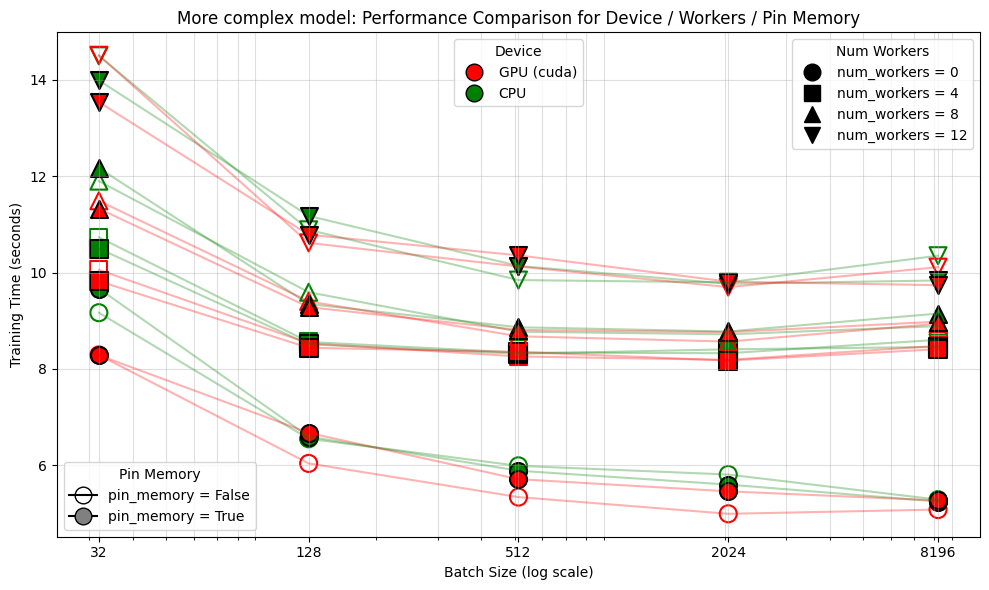

In [ ]:
# complete overview for cplx_model
color_map  = {"cuda": "red", "cpu": "green"}
marker_map = {0:"o", 4:"s", 8:"^", 12:"v"}

plt.figure(figsize = (10, 6))

for _, row in timings_df.iterrows():
    batch   = row["batch_size"]
    workers = row["num_workers"]
    pin     = row["pin_memory"]
    device  = row["device"]
    t       = row["time"]

    color  = color_map[device]
    marker = marker_map[workers]

    if pin:
        facecolor = color
        edgecolor = "black"
    else:
        facecolor = "none"
        edgecolor = color

    plt.scatter(
        batch, t,
        marker    = marker,
        facecolor = facecolor,
        edgecolor = edgecolor,
        s         = 150,
        linewidth = 1.5,
    )

for (device, pin, workers), group in timings_df.groupby(["device", "pin_memory", "num_workers"]):
    plt.plot(group["batch_size"], group["time"], color = color_map[device], alpha = 0.3)

# legend for device (color)
device_handles = [
    Line2D([0], [0], 
           marker          = 'o', 
           color           = 'none', 
           markerfacecolor = 'red', 
           markeredgecolor = 'black', 
           markersize      = 12, 
           label           = 'GPU (cuda)'
    ),
    Line2D([0], [0], 
           marker          = 'o', 
           color           = 'none', 
           markerfacecolor = 'green', 
           markeredgecolor = 'black', 
           markersize      = 12, 
           label           = 'CPU'
    ),
]

# legend for pin_memory (filled vs hollow)
pin_handles = [
    Line2D([0], [0], 
           marker          = 'o', 
           color           = 'black', 
           markerfacecolor = 'none',
           markersize      = 12, 
           label           = 'pin_memory = False'
    ),
    Line2D([0], [0], 
           marker          = 'o', 
           color           = 'black', 
           markerfacecolor = 'gray',
           markersize      = 12, 
           label           = 'pin_memory = True'
    ),
]

# legend for num_workers (marker shapes)
marker_handles = [
    Line2D([0], [0], 
           marker          = marker_map[w], 
           color           = 'black',
           markerfacecolor = 'black', 
           markersize      = 12, 
           linestyle       = 'none',
           label           = f"num_workers = {w}")
    for w in sorted(marker_map.keys())
]

# legends
legend1 = plt.legend(handles = device_handles, title = "Device", loc = "upper center")
plt.gca().add_artist(legend1)

legend2 = plt.legend(handles = pin_handles, title = "Pin Memory", loc = "lower left")
plt.gca().add_artist(legend2)

plt.legend(handles = marker_handles, title = "Num Workers", loc = "upper right")

plt.xscale("log")
plt.xticks([32, 128, 512, 2048, 8192], ["32", "128", "512", "2024", "8196"])
plt.xlabel("Batch Size (log scale)")
plt.ylabel("Training Time (seconds)")
plt.title("More complex model: Performance Comparison for Device / Workers / Pin Memory")
plt.grid(True, which = "both", alpha = 0.4)
plt.tight_layout()
plt.show()

In [ ]:
# cnn model
class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 8 Filter, 3x3 Kernel, 1 Stride
        # 1x28x28 -> 8x26x26
        self.conv1 = nn.Conv2d(
            in_channels  = 1,
            out_channels = 8,
            kernel_size  = 3
        )

        # 8x26x26 -> 8x13x13
        self.pool1 = nn.MaxPool2d(kernel_size = 2)

        # 8x13x13 -> 16x11x11
        self.conv2 = nn.Conv2d(
            in_channels = 8,
            out_channels = 16,
            kernel_size = 3
        )

        # 16x11x11 -> 16x5x5
        self.pool2 = nn.MaxPool2d(kernel_size = 2)

        # 16x5x5 = 400 -> 64
        self.fc1 = nn.Linear(16 * 5 * 5, 64) 
        # 64 -> 10
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = torch.flatten(x, 1) # Batch x Channels x Height x Width, Start Dimension 1, alles nach Batch wird platt

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x    
    
cnn_model_gpu = DigitCNN().cuda()
cnn_model_cpu = DigitCNN()

In [ ]:
# loss function, optimizer with learning rate lr
cnn_lr = 0.001
cnn_loss_fn_gpu = nn.CrossEntropyLoss()
cnn_loss_fn_cpu = nn.CrossEntropyLoss()
cnn_optimizer_gpu = torch.optim.Adam(params = cnn_model_gpu.parameters(), lr = cnn_lr)
cnn_optimizer_cpu = torch.optim.Adam(params = cnn_model_cpu.parameters(), lr = cnn_lr)

In [ ]:
# gpu traning for cnn_model_gpu
epochs = 10
start = time.time()

for epoch in range(epochs):
    total_loss = 0
    for X, y in train_loader:
        X, y = X.cuda(non_blocking = True), y.cuda(non_blocking = True)

        preds = cnn_model_gpu(X)
        loss = cnn_loss_fn_gpu(preds, y)

        cnn_optimizer_gpu.zero_grad()   # delete old gradients
        loss.backward()                 # calculate new gradients through backpropagations (chain rule)
        cnn_optimizer_gpu.step()        # update weights and bias

        total_loss += loss.item()

    print(f"epoch {epoch + 1}: loss = {total_loss:.4f}")

print(f"{epochs} epochs in {time.time()-start}s")

epoch 1: loss = 32.9374
epoch 2: loss = 24.9638
epoch 3: loss = 13.1558
epoch 4: loss = 7.6430
epoch 5: loss = 5.9496
epoch 6: loss = 5.0742
epoch 7: loss = 4.4748
epoch 8: loss = 4.0188
epoch 9: loss = 3.6408
epoch 10: loss = 3.3121
10 epochs in 71.3846595287323s


In [ ]:
# cpu traning for cnn_model_cpu
epochs = 10
start = time.time()

for epoch in range(epochs):
    total_loss = 0
    for X, y in train_loader:

        preds = cnn_model_cpu(X)
        loss = cnn_loss_fn_cpu(preds, y)

        cnn_optimizer_cpu.zero_grad()   # delete old gradients
        loss.backward()                 # calculate new gradients through backpropagations (chain rule)
        cnn_optimizer_cpu.step()        # update weights and bias

        total_loss += loss.item()

    print(f"epoch {epoch + 1}: loss = {total_loss:.4f}")

print(f"{epochs} epochs in {time.time()-start}s")

epoch 1: loss = 33.7118
epoch 2: loss = 28.3651
epoch 3: loss = 16.8425
epoch 4: loss = 8.9953
epoch 5: loss = 6.4921
epoch 6: loss = 5.2887
epoch 7: loss = 4.5461
epoch 8: loss = 4.0013
epoch 9: loss = 3.5657
epoch 10: loss = 3.2183
10 epochs in 84.29484939575195s


In [ ]:
# eval cnn_model_gpu
correct = 0
total = 0
cnn_model_gpu.eval()

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.cuda(non_blocking = True), y.cuda(non_blocking = True)
        preds = cnn_model_gpu(X)
        correct += (preds.argmax(1) == y).sum().item()
        total += y.size(0)

print("Accuracy:", correct / total)

Accuracy: 0.9414


In [ ]:
# eval cnn_model_cpu
correct = 0
total = 0
cnn_model_cpu.eval()

with torch.no_grad():
    for X, y in test_loader:
        preds = cnn_model_cpu(X)
        correct += (preds.argmax(1) == y).sum().item()
        total += y.size(0)

print("Accuracy:", correct / total)

Accuracy: 0.946


In [ ]:
# Run the benchmark for cnn_model
epochs = 1
results = []

for batch_size, num_workers, pin_memory, device in itertools.product(
    batch_sizes, num_workers_list, pin_memory_list, devices
):
    print(f"Testing: batch={batch_size}, workers={num_workers}, pin={pin_memory}, device={device}")

    loader = DataLoader(
        dataset     = train_data,
        batch_size  = batch_size,
        num_workers = num_workers,
        pin_memory  = pin_memory,
        shuffle     = True
    )

    cnn_model = DigitCNN()
    t = benchmark(cnn_model, loader, device, epochs = epochs)

    results.append({
    "batch_size": batch_size,
    "num_workers": num_workers,
    "pin_memory": pin_memory,
    "device": device,
    "time": t
    })

timings_df = pd.DataFrame(results)

Testing: batch=32, workers=0, pin=False, device=cpu
Testing: batch=32, workers=0, pin=False, device=cuda
Testing: batch=32, workers=0, pin=True, device=cpu
Testing: batch=32, workers=0, pin=True, device=cuda
Testing: batch=32, workers=4, pin=False, device=cpu
Testing: batch=32, workers=4, pin=False, device=cuda
Testing: batch=32, workers=4, pin=True, device=cpu
Testing: batch=32, workers=4, pin=True, device=cuda
Testing: batch=32, workers=8, pin=False, device=cpu
Testing: batch=32, workers=8, pin=False, device=cuda
Testing: batch=32, workers=8, pin=True, device=cpu
Testing: batch=32, workers=8, pin=True, device=cuda
Testing: batch=32, workers=12, pin=False, device=cpu
Testing: batch=32, workers=12, pin=False, device=cuda
Testing: batch=32, workers=12, pin=True, device=cpu
Testing: batch=32, workers=12, pin=True, device=cuda
Testing: batch=128, workers=0, pin=False, device=cpu
Testing: batch=128, workers=0, pin=False, device=cuda
Testing: batch=128, workers=0, pin=True, device=cpu
Testi

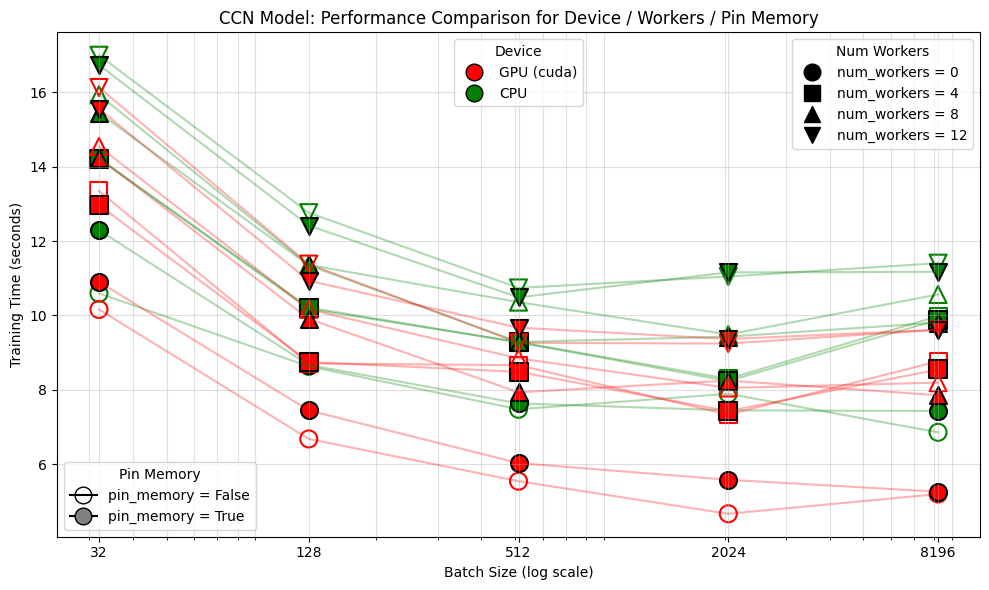

In [ ]:
# complete overview for cnn_model
color_map  = {"cuda": "red", "cpu": "green"}
marker_map = {0:"o", 4:"s", 8:"^", 12:"v"}

plt.figure(figsize = (10, 6))

for _, row in timings_df.iterrows():
    batch   = row["batch_size"]
    workers = row["num_workers"]
    pin     = row["pin_memory"]
    device  = row["device"]
    t       = row["time"]

    color  = color_map[device]
    marker = marker_map[workers]

    if pin:
        facecolor = color
        edgecolor = "black"
    else:
        facecolor = "none"
        edgecolor = color

    plt.scatter(
        batch, t,
        marker    = marker,
        facecolor = facecolor,
        edgecolor = edgecolor,
        s         = 150,
        linewidth = 1.5,
    )

for (device, pin, workers), group in timings_df.groupby(["device", "pin_memory", "num_workers"]):
    plt.plot(group["batch_size"], group["time"], color = color_map[device], alpha = 0.3)

# legend for device (color)
device_handles = [
    Line2D([0], [0], 
           marker          = 'o', 
           color           = 'none', 
           markerfacecolor = 'red', 
           markeredgecolor = 'black', 
           markersize      = 12, 
           label           = 'GPU (cuda)'
    ),
    Line2D([0], [0], 
           marker          = 'o', 
           color           = 'none', 
           markerfacecolor = 'green', 
           markeredgecolor = 'black', 
           markersize      = 12, 
           label           = 'CPU'
    ),
]

# legend for pin_memory (filled vs hollow)
pin_handles = [
    Line2D([0], [0], 
           marker          = 'o', 
           color           = 'black', 
           markerfacecolor = 'none',
           markersize      = 12, 
           label           = 'pin_memory = False'
    ),
    Line2D([0], [0], 
           marker          = 'o', 
           color           = 'black', 
           markerfacecolor = 'gray',
           markersize      = 12, 
           label           = 'pin_memory = True'
    ),
]

# legend for num_workers (marker shapes)
marker_handles = [
    Line2D([0], [0], 
           marker          = marker_map[w], 
           color           = 'black',
           markerfacecolor = 'black', 
           markersize      = 12, 
           linestyle       = 'none',
           label           = f"num_workers = {w}")
    for w in sorted(marker_map.keys())
]

# legends
legend1 = plt.legend(handles = device_handles, title = "Device", loc = "upper center")
plt.gca().add_artist(legend1)

legend2 = plt.legend(handles = pin_handles, title = "Pin Memory", loc = "lower left")
plt.gca().add_artist(legend2)

plt.legend(handles = marker_handles, title = "Num Workers", loc = "upper right")

plt.xscale("log")
plt.xticks([32, 128, 512, 2048, 8192], ["32", "128", "512", "2024", "8196"])
plt.xlabel("Batch Size (log scale)")
plt.ylabel("Training Time (seconds)")
plt.title("CNN Model: Performance Comparison for Device / Workers / Pin Memory")
plt.grid(True, which = "both", alpha = 0.4)
plt.tight_layout()
plt.show()

Erkenntnis:
- Overhead beim Laden oder Vorbereiten der Daten für mehrere Worker dominiert.
- Der Spalt zwischen CPU und GPU wird größer, wenn es mehr zu berechnen gibt.
- Bei der Effizenz und Geschwindigkeit der GPU kommt es auf die Batchsize, die Modelgröße und die Effiziens des Dataloaders an.
- 

In [ ]:
# cnn_model_final
class DigitCNNFinal(nn.Module):
    def __init__(self):
        super().__init__()
        #1x28x28
        self.conv1 = nn.Conv2d(1, 8, 3)
        # 8x 26x26
        self.pool1 = nn.MaxPool2d(2)
        # 8x 13x13 
        self.conv2 = nn.Conv2d(8, 16, 3)
        # 16x 11x11
        self.pool2 = nn.MaxPool2d(2)
        # 16x 5x5 = 400
        self.fc1 = nn.Linear(16*5*5, 64)
        
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(64, 10)

        # better initialization
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# loader, model and parameters
train_loader = DataLoader(train_data, batch_size = 512, num_workers = 0, pin_memory= True)
test_loader = DataLoader(test_data, batch_size = 512, num_workers = 0, pin_memory= True)

cnn_model_gpu_final = DigitCNNFinal().cuda()

cnn_lr_final = 0.001
cnn_loss_fn_gpu_final = nn.CrossEntropyLoss()
cnn_optimizer_gpu_final = torch.optim.Adam(params = cnn_model_gpu_final.parameters(), lr = cnn_lr_final)
scheduler = torch.optim.lr_scheduler.StepLR(cnn_optimizer_gpu_final, step_size = 25 , gamma = 0.5)            # learning rate decay 

# training 
epochs = 100
best_acc = 0.0

for epoch in range(epochs):
    cnn_model_gpu_final.train()
    total_loss = 0

    for X, y in train_loader:
        X, y = X.cuda(non_blocking = True), y.cuda(non_blocking = True)

        preds = cnn_model_gpu_final(X)
        loss = cnn_loss_fn_gpu_final(preds, y)

        cnn_optimizer_gpu_final.zero_grad()
        loss.backward()
        cnn_optimizer_gpu_final.step()

        total_loss += loss.item()

    # eval
    cnn_model_gpu_final.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.cuda(), y.cuda()
            preds = cnn_model_gpu_final(X)
            predicted = preds.argmax(1)
            correct += (predicted == y).sum().item()
            total += y.size(0)

    acc = correct / total

    print(f"Epoch {epoch + 1}/{epochs} | loss = {total_loss:.3f} | acc = {acc:.4f} | lr = {scheduler.get_last_lr()[0]:.6f}")

    scheduler.step()
    
    # save the best model
    if acc > best_acc:
        best_acc = acc
        torch.save(cnn_model_gpu_final.state_dict(), "mnist_digitcnn_final_best.pth")

Epoch 1/100 - loss = 100.579 - acc = 0.9200 - lr = 0.001000
Epoch 2/100 - loss = 34.203 - acc = 0.9525 - lr = 0.001000
Epoch 3/100 - loss = 22.674 - acc = 0.9668 - lr = 0.001000
Epoch 4/100 - loss = 17.570 - acc = 0.9747 - lr = 0.001000
Epoch 5/100 - loss = 14.775 - acc = 0.9764 - lr = 0.001000
Epoch 6/100 - loss = 13.072 - acc = 0.9794 - lr = 0.001000
Epoch 7/100 - loss = 11.560 - acc = 0.9787 - lr = 0.001000
Epoch 8/100 - loss = 10.740 - acc = 0.9796 - lr = 0.001000
Epoch 9/100 - loss = 9.995 - acc = 0.9814 - lr = 0.001000
Epoch 10/100 - loss = 9.123 - acc = 0.9825 - lr = 0.001000
Epoch 11/100 - loss = 8.672 - acc = 0.9834 - lr = 0.001000
Epoch 12/100 - loss = 8.083 - acc = 0.9818 - lr = 0.001000
Epoch 13/100 - loss = 7.819 - acc = 0.9846 - lr = 0.001000
Epoch 14/100 - loss = 7.210 - acc = 0.9841 - lr = 0.001000
Epoch 15/100 - loss = 6.951 - acc = 0.9841 - lr = 0.001000
Epoch 16/100 - loss = 6.662 - acc = 0.9860 - lr = 0.001000
Epoch 17/100 - loss = 6.176 - acc = 0.9855 - lr = 0.0010

In [ ]:
# final eval after lodaing

model = DigitCNN().cuda()
model.load_state_dict(torch.load("mnist_digitcnn_final_best.pth"))
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.cuda(), y.cuda()*
        preds = model(X)
        predicted = preds.argmax(1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

acc = correct / total

acc = correct / total
print("Test accuracy:", acc)

Test accuracy: 0.9913


Was wurde erreicht?
- Full Pipeline : Daten -> Model -> Training -> GPU/CPU Tests -> Evaluation
- Scheduler, Batchsize, Devices, Workers, nn.Linear, nn.Conv2d
- Das Model wurde selbst trainiert von Anfang bis Ende und als benutzbares Model gepeichert.
- Für ein vergleichsweise einfaches Model (auch das cnn_final) war die Genauigkeit mit 99,13% nicht schlecht. 

In [ ]:
# Note: more tweeking is possible later:

# BatchNorm 
# More channels 
# Dropout 
# OneCycleLR

In [ ]:
# real life test
from IPython.display import display

model = DigitCNN().cuda()
model.load_state_dict(torch.load("mnist_digitcnn_final_best.pth"))

ROOT = Path().resolve()
TEST = ROOT / "data" / "test"

# convert to grey
image_1 = PIL.Image.open(TEST / "1.jpg").convert("L")
image_1_2 = PIL.Image.open(TEST / "1_2.jpg").convert("L")
image_7 = PIL.Image.open(TEST / "7.jpg").convert("L")

transformer = transforms.Compose([transforms.ToTensor()])

# invert
image_1_inv = ImageOps.invert(image_1)
image_1_2_inv = ImageOps.invert(image_1_2)
image_7_inv = ImageOps.invert(image_7)

# transform to tensor
tensor_1 = transformer(image_1_inv).unsqueeze(0).cuda()
tensor_1_2 = transformer(image_1_2_inv).unsqueeze(0).cuda()
tensor_7 = transformer(image_7_inv).unsqueeze(0).cuda()


preds_1 = model(tensor_1).argmax(1).item()
preds_1_2 = model(tensor_1_2).argmax(1).item()
preds_7 = model(tensor_7).argmax(1).item()

display(image_1)
print("Vorhersage", preds_1)

display(image_1_2)
print("Vorhersage:", preds_1_2)

display(image_7)
print("Vorhersage:", preds_7)

Vorhersage 7


Vorhersage: 7


Vorhersage: 3


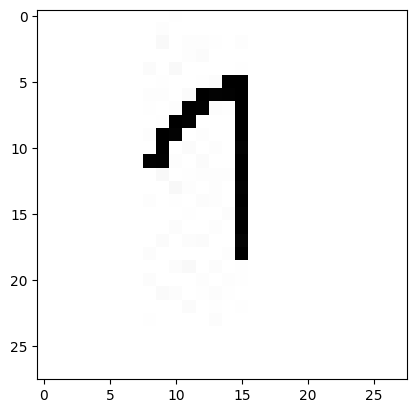

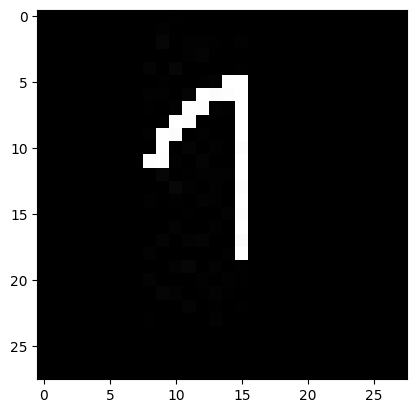

0.0
1.0
0.035154059529304504


In [26]:
plt.imshow(image_1, cmap="gray")
plt.show()

plt.imshow(image_1_inv, cmap="gray")
plt.show()

print(tensor_1.min().item())
print(tensor_1.max().item())
print(tensor_1.mean().item())

In [27]:
print(tensor_1.shape)

torch.Size([1, 1, 28, 28])


In [28]:
model = DigitCNN().cuda()
model.load_state_dict(torch.load("mnist_digitcnn_final_best.pth"))
model.eval()

DigitCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=400, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

In [29]:
model.eval()
print(model.training)

False


In [30]:
with torch.no_grad():
    logits = model(tensor_1)
    probs = torch.softmax(logits, dim=1)

print(probs.cpu().numpy())
print("prediction:", probs.argmax(1).item())

[[2.8674977e-04 1.5928811e-01 9.2651444e-03 1.0059896e-01 3.2278426e-02
  2.5953408e-04 1.7629460e-05 6.7107493e-01 4.0202946e-03 2.2910157e-02]]
prediction: 7


In [31]:
model.eval()

for i in range(10):
    img, label = test_data[i]

    with torch.no_grad():
        pred = model(img.unsqueeze(0).cuda()).argmax(1).item()

    print(f"Label={label}, Pred={pred}")

Label=7, Pred=7
Label=2, Pred=2
Label=1, Pred=1
Label=0, Pred=0
Label=4, Pred=4
Label=1, Pred=1
Label=4, Pred=4
Label=9, Pred=9
Label=5, Pred=5
Label=9, Pred=9


In [32]:
import torch.nn.functional as F

thicker = F.max_pool2d(
    tensor_1,
    kernel_size=3,
    stride=1,
    padding=1
)

with torch.no_grad():
    probs = torch.softmax(model(thicker), dim=1)

print(probs.cpu().numpy())

[[2.8962785e-07 1.8062496e-01 1.2432374e-05 3.9611452e-05 2.0762991e-02
  1.7579579e-06 1.8232462e-06 7.9851848e-01 1.9293752e-06 3.5708035e-05]]


In [34]:
img = tensor_7.squeeze().cpu().numpy()

for row in img:
    print("".join("#" if p > 0.5 else "." for p in row))

............................
............................
............................
............................
............................
............................
............................
.......##########...........
................#...........
...............##...........
...............#............
..............##............
..............#.............
.............##.............
............##..............
............#...............
............#...............
...........##...............
...........#................
..........##................
............................
............................
............................
............................
............................
............................
............................
............................


In [35]:
with torch.no_grad():
    probs = torch.softmax(model(tensor_7), dim=1)

for i, p in enumerate(probs[0]):
    print(i, float(p))

0 8.605665513528038e-09
1 0.000438977062003687
2 8.584234819863923e-06
3 0.7411364316940308
4 4.706396066467278e-05
5 1.0058970474347007e-06
6 2.6395888252928046e-10
7 0.04464414343237877
8 5.574532679020194e-06
9 0.2137182652950287
